# Data preperation

In [1]:
from mcgs import monte_carlo_grain_structure as mcgs

PXGS = mcgs()
PXGS.simulate()


////////////////////////////////
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
////////////////////////////////


In [2]:
tslice = 8


In [3]:
PXGS.detect_grains(8)
PXGS.gs[tslice].char_morph_2d()

////////////////////////////////
Using opencv for grain identification
Temporal slice number = 8. |||| No. of grains detected = 73
////////////////////////////////
Extracting requested grain structure properties across all available states


c:\Development\M2MatMod\upxo\mcgs.py:2990: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  nonNone = np.argwhere(np.array(list(self.s_gid.values())) != None)


////////////////////////////////







In [4]:
PXGS.gs[tslice].neigh()

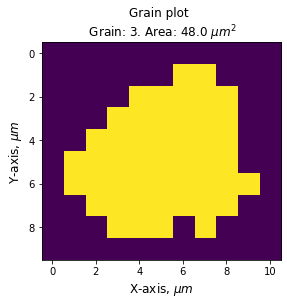

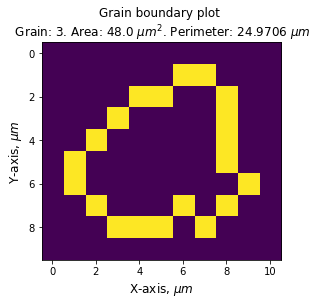

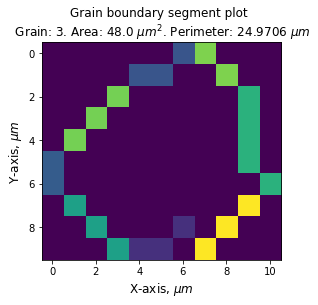

In [5]:
grain_number = 3
PXGS.gs[tslice].g[grain_number]["grain"].plot()
PXGS.gs[tslice].g[grain_number]["grain"].plotgb()
PXGS.gs[tslice].g[grain_number]["grain"].plotgbseg()


In [ ]:
PXGS.gs[tslice].plot_grain(grain_number, neigh=True)


In [ ]:
neighbours = PXGS.gs[tslice].g[grain_number]["grain"].neigh
print(neighbours)


In [ ]:
from copy import deepcopy
import numpy as np
import seaborn as sns

In [ ]:
PXGS.gs[tslice].plot_grains_gids(gids=neighbours)


In [ ]:
PXGS.gs[tslice].plot_neigh_grains(gids=[2, 3], throw=False)

In [ ]:
PXGS.gs[tslice].g[1]["grain"].plotgbseg()
PXGS.gs[tslice].g[1]["grain"].plot()


# GB Segments identification

In [ ]:
gid = 1
print("-" * 80)
print("Getting the bounds and probable grain locations")
bounds = PXGS.gs[tslice].g[gid]["grain"].bbox_ex_bounds
print(f"bounds: {bounds}")

probable_grains_locs = PXGS.gs[tslice].lgi[bounds[0] : bounds[1], bounds[2] : bounds[3]]
print(probable_grains_locs)
print("-" * 80)

In [ ]:
print(PXGS.gs[tslice].g[gid]["grain"].gbloc)
print(bounds, bounds[1] - bounds[0] + 1, bounds[3] - bounds[2] + 1)
gbloc_bbox_ex = [
    [_gbloc_[0] - bounds[0], _gbloc_[1] - bounds[2]]
    for _gbloc_ in PXGS.gs[tslice].g[gid]["grain"].gbloc
]
print(probable_grains_locs)
gbloc_bbox_ex


In [ ]:
from dataclasses import dataclass


@dataclass
class GrainPoints:
    gid = None
    neigh_s = []  # State value of neighbouring pixels
    neigh_order = []  # Numeber of neigbouring pixels having a different state value


gbp = GrainPoints()  # Grain Boundary Points Data-Class

In [ ]:
NO = []
for _gbloc_bbx_ in gbloc_bbox_ex:
    # _gbloc_bbx_ = gbloc_bbox_ex[0]
    r = _gbloc_bbx_[0]
    c = _gbloc_bbx_[1]
    if r == 0 and c == 0:
        local = probable_grains_locs[r : r + 2, c : c + 2]
    elif r == 0 and c != 0:
        local = probable_grains_locs[r : r + 2, c - 1 : c + 2]
    elif r != 0 and c == 0:
        local = probable_grains_locs[r - 1 : r + 2, c : c + 2]
    elif r != 0 and c != 0:
        local = probable_grains_locs[r - 1 : r + 2, c - 1 : c + 2]
    print(local)
    locals_others = np.unique(local[local != gid].flatten())
    print(locals_others)
    gbp.gid = gid
    gbp.neigh_s = locals_others
    # print(gbp.neigh_s)
    gbp.neigh_order = len(locals_others)
    # print(gbp.neigh_order)
    NO.append(len(locals_others))

In [ ]:
print(gbloc_bbox_ex)
print(NO)
print(probable_grains_locs)
PXGS.gs[tslice].g[1]["grain"].plotgb()


In [ ]:
print(local)


In [ ]:
temp = deepcopy(probable_grains_locs)
""" For row, col of a location in probable_grains_locs with value = 2,
    replace the value immediate neighbourhood of row and col to be nan.
    If the immediate neighbourhood has value == 2, then ignore """
for row in range(temp.shape[0]):
    for col in range(temp.shape[1]):
        if temp[row, col] == gid:
            if row - 1 >= 0:
                if temp[row - 1, col] != gid:
                    temp[row - 1, col] = -1
            if row + 1 < temp.shape[0]:
                if temp[row + 1, col] != gid:
                    temp[row + 1, col] = -1
            if col - 1 >= 0:
                if temp[row, col - 1] != gid:
                    temp[row, col - 1] = -1
            if col + 1 < temp.shape[1]:
                if temp[row, col + 1] != gid:
                    temp[row, col + 1] = -1
"""
    if values in probable_grains_locs not equal to -1,
    then replace them with 0
    """
for row in range(temp.shape[0]):
    for col in range(temp.shape[1]):
        if temp[row, col] != -1:
            temp[row, col] = 0
""" Find out the gids of the neighbouring grains """
neigh_pixel_locs = np.argwhere(temp == -1)
neigh_pixel_grain_ids = probable_grains_locs[
    neigh_pixel_locs[:, 0], neigh_pixel_locs[:, 1]
]
neighbour_ids = np.unique(neigh_pixel_grain_ids)
""" Store the neighbnour_ids inside the grain object """
PXGS.gs[tslice].g[gid]["grain"].neigh = tuple(neighbour_ids)
print(neighbour_ids)
print(neighbour_ids)

In [ ]:
print(PXGS.gs[tslice].g[gid]["grain"].bbox_ex)
print("------------------------")
print(temp)